In [2]:
import importlib
import scipy
import pickle
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os


import iMSM.extensions.npc.npc
importlib.reload(iMSM.extensions.npc.npc)
from iMSM.extensions.npc.npc import run

import iMSM.extensions.npc.npc_utils
importlib.reload(iMSM.extensions.npc.npc_utils)
from iMSM.extensions.npc.npc_utils import radius_a_to_kda, amount_to_concentration

import iMSM.extensions.npc.npc_graph_figure
importlib.reload(iMSM.extensions.npc.npc_graph_figure)
from iMSM.extensions.npc.npc_graph_figure import estimate_cluters_mu_cov, calc_coordinate_edges_dict, get_sorted_anchor_coordinates_np

In [6]:
for sites in [2,4,6]:
    for radius in [10, 14, 18, 22, 26]:
        print (f"~~~~~~~ Running for {sites} sites and radius {radius} ~~~~~~~")
        for subset in [1.0]: #             
            checkpoint_path = f"data/ntr_variants_dilated/{sites}_{radius}/"
            params = {}
            params['LOAD_MD_KAP_SITES'] = sites
            params['LOAD_MD_KAP_RADIUS'] = radius
            params['LOAD_MD_KAP_AMOUNT'] = 100
            params['LOAD_MD_BASE_PATH'] = f"/cs/usr/roi.eliasian/LabFolder/NpcTransportExperiment/HS-AFM-Dataset/dataset/full_dilated/{sites}_sites_small"
            params['LOAD_MD_SIMS_RANGE'] = range(1, 31)
            params['LOAD_MD_START_TIME_NS'] = 10000
            params['LOAD_MD_END_TIME_NS'] = 30000
            params['LOAD_MD_STEP_NS'] = 100
            
            params['CUSTOM_FG_COORDS_PATH'] = f"data/ntr_variants_dilated/{sites}_{10}/2_single_sim_fg_coords/"
            params['TM_PRIOR'] = 0.0001
            params['STATE_CHOICE_METHOD'] = "distance" # options: "prominent", "distance", "nuc_cyt_treshold"
            params['DISTANCE_STATE_THRESHOLD_NM'] = 10
            
            # bootstraps:
            # params['BOOTSTRAP_REPEATS'] = 100
            # params['N_CLUSTERS'] = [640]
            
            params['MODE'] = "subset"
            params['N_CLUSTERS'] = [80]
            params['DATA_SUBSET'] = subset
            params['DATA_SUBSET_INDEX'] = 0
            params['DATA_SUBSET_MODE'] = "simulation" 
            
            run(checkpoint_path, params_override=params, start_stage=6, end_stage=8)

~~~~~~~ Running for 2 sites and radius 10 ~~~~~~~
Running stage 6...
Stage 6 completed.
Running stage 7...
Permeability for 80 clusters: 1801.284931579904 (units: n_events / s / uM / NPC)
Stage 7 completed.
~~~~~~~ Running for 2 sites and radius 14 ~~~~~~~
Running stage 6...
Stage 6 completed.
Running stage 7...
Permeability for 80 clusters: 903.109134645248 (units: n_events / s / uM / NPC)
Stage 7 completed.
~~~~~~~ Running for 2 sites and radius 18 ~~~~~~~
Running stage 6...
Stage 6 completed.
Running stage 7...
Permeability for 80 clusters: 514.9171235430399 (units: n_events / s / uM / NPC)
Stage 7 completed.
~~~~~~~ Running for 2 sites and radius 22 ~~~~~~~
Running stage 6...
Stage 6 completed.
Running stage 7...
Permeability for 80 clusters: 333.616962678784 (units: n_events / s / uM / NPC)
Stage 7 completed.
~~~~~~~ Running for 2 sites and radius 26 ~~~~~~~
Running stage 6...
Stage 6 completed.
Running stage 7...
Permeability for 80 clusters: 338.550300389376 (units: n_events / s

In [7]:
def poisson_confidence_interval(count, alpha=0.05):
    lower = scipy.stats.chi2.ppf(alpha/2, 2*count) / 2
    upper = scipy.stats.chi2.ppf(1-alpha/2, 2*(count+1)) / 2
    
    return lower, upper

# Collect data
def collect_perms_md(n_sites=None, radii=None, shorten_time_to=None):
    results = []
    for sites in n_sites:
        for radius in radii:
            for tunnel_diameter_nm in [54, 62]:
                if tunnel_diameter_nm == 62:
                    kap_coords_folder = f"data/ntr_variants_dilated/{sites}_{radius}/1_single_sim_kap_coords/"
                    n_trajs, total_full_transports, permeability, lower_permeability, upper_permeability = collect_perms_md_single_type(kap_coords_folder, n_sims=30, start_time=10, end_time=30, shorten_time_to=shorten_time_to)
                if tunnel_diameter_nm == 54:
                    kap_coords_folder = f"data/ntr_variants/{sites}_{radius}_more/1_single_sim_kap_coords/"
                    n_trajs, total_full_transports, permeability, lower_permeability, upper_permeability = collect_perms_md_single_type(kap_coords_folder, n_sims=30, start_time=10, end_time=70, shorten_time_to=shorten_time_to)
                
                results.append({
                    'sites': sites,
                    'radius': radius,
                    'kda': radius_a_to_kda(radius),
                    'tunnel_diameter_nm': tunnel_diameter_nm,
                    'total_transports': total_full_transports,
                    'n_trajs': n_trajs,
                    'permeability': permeability,
                    'lower_permeability': lower_permeability if lower_permeability >=0 else 0,
                    'upper_permeability': upper_permeability if upper_permeability >=0 else 0
                })
    return results

def collect_perms_md_single_type(kap_coords_folder, n_sims, start_time, end_time, shorten_time_to, step_ns=100):
    """
    Count transport events from raw 3D kap coordinates.
    
    kap_coords_folder: path containing subfolders 1, 2, ..., n_sims,
                       each with a file 'start_time-end_time.pickle' of shape (kap_amount, 3, n_frames).
    step_ns: time per frame in nanoseconds (default 100 ns).
    """
    # Load and concatenate raw 3D coordinates across all simulations
    all_coords = []
    for sim_idx in range(1, n_sims + 1):
        path = os.path.join(kap_coords_folder, str(sim_idx), f"{start_time}-{end_time}.pickle")
        with open(path, "rb") as f:
            coords = pickle.load(f)  # shape: (kap_amount, 3, n_frames)
        all_coords.append(coords)

    all_coords = np.concatenate(all_coords, axis=0)  # shape: (kap_amount * n_sims, 3, n_frames)

    _, _, n_frames = all_coords.shape
    time_us = n_frames * step_ns / 1000  # convert ns → µs

    if shorten_time_to is not None:
        if shorten_time_to > time_us:
            raise ValueError(f"shorten_time_to {shorten_time_to} µs is greater than trajectory length {time_us} µs")
        n_frames_to_use = int(shorten_time_to * 1000 / step_ns)
        time_us = shorten_time_to
        all_coords = all_coords[:, :, :n_frames_to_use]

    # Count transport events across all kap trajectories
    # z-axis is index 2 in the (kap_amount, 3, n_frames) array
    total_full_transports = 0
    n_trajs = all_coords.shape[0]
    for i in range(n_trajs):
        z = all_coords[i, 2, :]  # shape: (n_frames,)
        last_side = None

        for z_val in z:
            if z_val >= 10:
                current_side = 1   # cytoplasmic side (top)
            elif z_val <= -10:
                current_side = 0   # nuclear side (bottom)
            else:
                continue           # inside the channel, not yet committed

            if last_side is None:
                last_side = current_side   # initialise, don't count
            elif last_side != current_side:
                total_full_transports += 1
                last_side = current_side

    concentration_M = amount_to_concentration(100, box_side_a=800)
    concentration_uM = concentration_M * 1e6
            
    time_s = time_us * 1e-6

    lower, upper = poisson_confidence_interval(total_full_transports)
    rate = total_full_transports / (time_s * n_sims)
    lower_rate = lower / (time_s * n_sims)
    upper_rate = upper / (time_s * n_sims)
    permeability = rate / concentration_uM
    lower_permeability = lower_rate / concentration_uM
    upper_permeability = upper_rate / concentration_uM
    return n_trajs, total_full_transports, permeability, lower_permeability, upper_permeability

def collect_perms_msm(n_clusters=160):
    results = []
    for sites in n_sites:
        for radius in radii:
            for tunnel_diameter_nm in [54, 62]:
                if tunnel_diameter_nm == 54:
                    with open(f"data/ntr_variants/{sites}_{radius}_more/7_permeabilities_subsets/1.00fraction_simulations/0index/7_permeabilities.pickle", "rb") as f:
                        perms_dict = pickle.load(f)
                elif tunnel_diameter_nm == 62:
                    with open(f"data/ntr_variants_dilated/{sites}_{radius}/7_permeabilities_subsets/1.00fraction_simulations/0index/7_permeabilities.pickle", "rb") as f:
                        perms_dict = pickle.load(f)
                permeability = perms_dict[n_clusters]
                results.append({
                    'sites': sites,
                    'radius': radius,
                    'kda': radius_a_to_kda(radius),
                    'tunnel_diameter_nm': tunnel_diameter_nm,
                    'permeability': permeability
                })
    return results


n_sites = [2,4,6]
radii = [10, 14, 18, 22, 26]
md_results = collect_perms_md(n_sites=n_sites, radii=radii, shorten_time_to=20)
print(md_results)
msm_results = collect_perms_msm(n_clusters=80)
print(msm_results)


[{'sites': 2, 'radius': 10, 'kda': 3.47830926343323, 'tunnel_diameter_nm': 54, 'total_transports': 197, 'n_trajs': 3000, 'permeability': 1012.362009361067, 'lower_permeability': 875.9225407648679, 'upper_permeability': 1164.0299634798173}, {'sites': 2, 'radius': 10, 'kda': 3.47830926343323, 'tunnel_diameter_nm': 62, 'total_transports': 458, 'n_trajs': 3000, 'permeability': 2353.6131994282673, 'lower_permeability': 2142.9698279688837, 'upper_permeability': 2579.3638072335298}, {'sites': 2, 'radius': 14, 'kda': 9.544480618860783, 'tunnel_diameter_nm': 54, 'total_transports': 61, 'n_trajs': 3000, 'permeability': 313.4725003605334, 'lower_permeability': 239.7816242477073, 'upper_permeability': 402.6685407315375}, {'sites': 2, 'radius': 14, 'kda': 9.544480618860783, 'tunnel_diameter_nm': 62, 'total_transports': 157, 'n_trajs': 3000, 'permeability': 806.8062714197335, 'lower_permeability': 685.539415909622, 'upper_permeability': 943.3437055155156}, {'sites': 2, 'radius': 18, 'kda': 20.285499

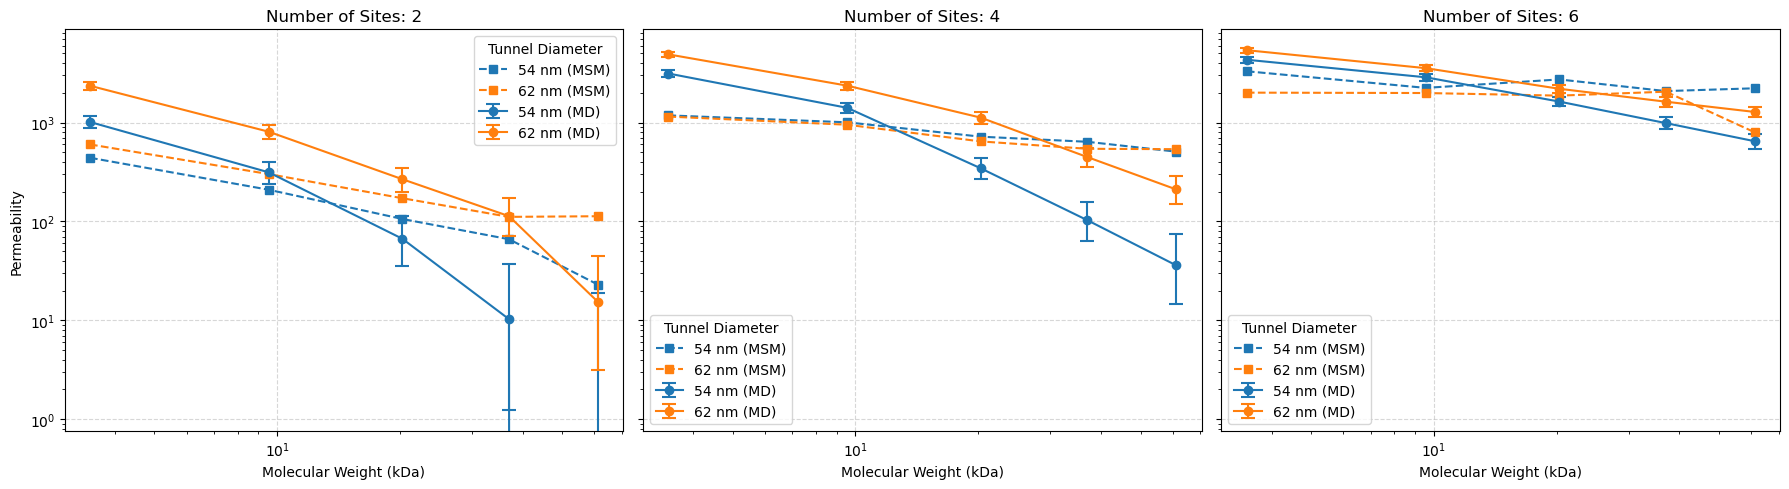

In [9]:

# Convert the results list of dicts to Pandas DataFrames
df_md = pd.DataFrame(md_results)
df_msm = pd.DataFrame(msm_results)

# Create a figure with 3 subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Get the unique site values (should be [2, 4, 6])
n_sites_list = sorted(df_md['sites'].unique())

color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
diameter_colors = {54: color_cycle[0], 62: color_cycle[1]}

for idx, sites in enumerate(n_sites_list):
    ax = axes[idx]
    
    # Filter data for the current number of sites
    df_md_sites = df_md[df_md['sites'] == sites]
    df_msm_sites = df_msm[df_msm['sites'] == sites]
    
    # Plot a line for each tunnel diameter
    for diameter in [54, 62]:
        color = diameter_colors[diameter]

        # MD data with error bars
        df_plot = df_md_sites[df_md_sites['tunnel_diameter_nm'] == diameter].sort_values('kda')
        x = df_plot['kda']
        y = df_plot['permeability']
        yerr_lower = np.maximum(0, y - df_plot['lower_permeability'])
        yerr_upper = np.maximum(0, df_plot['upper_permeability'] - y)
        
        ax.errorbar(
            x, y,
            yerr=[yerr_lower, yerr_upper],
            label=f'{diameter} nm (MD)',
            marker='o',
            capsize=5,
            capthick=1.5,
            elinewidth=1.5,
            linestyle='-',
            color=color
        )

        # MSM data (no error bars, dashed line)
        df_msm_plot = df_msm_sites[df_msm_sites['tunnel_diameter_nm'] == diameter].sort_values('kda')
        ax.plot(
            df_msm_plot['kda'],
            df_msm_plot['permeability'] / 3,
            label=f'{diameter} nm (MSM)',
            marker='s',
            linestyle='--',
            color=color
        )
        
    ax.set_title(f'Number of Sites: {sites}')
    ax.set_xlabel('Molecular Weight (kDa)')
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    
    if idx == 0:
        ax.set_ylabel('Permeability')
        
    ax.legend(title='Tunnel Diameter')
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
